# Why JAX

JAX is Python with **supercharged functions**. In 30 minutes, you'll see:

1. **JIT compilation:** Write once, run 100× faster. A galaxy SED evaluates in ~1 ms instead of 100 ms.
2. **Automatic differentiation:** Free gradients. The cost of `∇L/∇θ` is the same as the forward pass.
3. **Vectorization without loops:** `vmap` turns your single-galaxy model into a batch-of-1000 model with one decorator.
4. **One model, any inference method:** MAP, Laplace, Pathfinder, HMC, VI all use the same JAX forward model. No reimplementation.

This notebook uses real tengri physics (blackbody SEDs, photometric fitting) to teach JAX *via doing*, not toy examples.

**What you already know:** NumPy, the physics of stellar spectra and dust attenuation, the likelihood χ² and its role in Bayesian inference.

## Setup

In [1]:
import os
import sys
import time
import warnings

# Memory and compilation setup (safe defaults)
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

# nbconvert runs the kernel with cwd = notebooks/. Switch to repo root so
# relative ``data/...`` paths resolve identically to direct .py execution.
if os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)

import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

# Optional plot styling
try:
    from _plot_style import setup_style
    setup_style()
except ImportError:
    pass

W0507 02:35:02.203510 12748925 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0507 02:35:03.833900 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Load minimal tengri infrastructure (SSP grid for realistic SED models).

In [2]:
from tengri import (
    Fixed,
    Observation,
    Parameters,
    Photometry,
    SEDModel,
    Uniform,
    load_ssp_data,
)

_SSP_PATH = "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
if not os.path.exists(_SSP_PATH):
    _SSP_PATH = "data/ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"

ssp_data = load_ssp_data(_SSP_PATH)
print(
    f"✓ Loaded SSP grid: flux{tuple(ssp_data.ssp_flux.shape)}, "
    f"n_age={ssp_data.ssp_lg_age_gyr.size}, n_met={ssp_data.ssp_lgmet.size}"
)

✓ Loaded SSP grid: flux(15, 93, 5994), n_age=93, n_met=15


Set up a minimal 7-D model (smooth star formation history + dust).
This is our "single galaxy" model that we'll speed up, differentiate, and batch.

In [3]:
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)

spec = Parameters(
    mean_sfh_type="dpl",  # double power law SFH
    sfh_dpl_log_peak_sfr=Uniform(-1, 2.5),
    sfh_dpl_tau_gyr=Uniform(0.1, 10),
    sfh_dpl_alpha=Uniform(1, 10),
    sfh_dpl_beta=Uniform(1, 10),
    met_logzsol=Uniform(-2, 0.2),
    dust_tau_bc=Uniform(0, 2),
    dust_tau_diff=Uniform(0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)

model = SEDModel(spec, ssp_data, observation=obs)
params = spec.sample(jax.random.PRNGKey(42))

print(f"\n✓ Model: {len(spec.free_params)} free parameters")
for p in spec.free_params[:3]:
    print(f"  {p}: {params[p]:.4f}")
print("  ...")

W0507 02:35:04.222913 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 02:35:04.255730 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 02:35:04.262283 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0507 02:35:04.308002 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:636: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebu


✓ Model: 7 free parameters
  dust_tau_bc: 0.8933
  dust_tau_diff: 0.8712
  met_logzsol: -0.1187
  ...


---

## Idea 1: JIT Compilation — From Python to Machine Code

JAX's **JIT (Just-In-Time) compiler** converts Python functions into fused XLA kernels.
The **first call compiles** (~100–500 ms); **subsequent calls are pure compiled code** (~1–5 ms).
For inference with 1000+ likelihood evaluations, compilation is amortized to imperceptible overhead.

**We'll time it.**

In [4]:
def measure_speedup(model, params, n_warmup=1, n_timed=10):
    """Measure first-call (compile + exec) vs steady-state (pure JIT)."""
    times = []

    # Warm-up (trigger XLA compile if not cached)
    for _ in range(n_warmup):
        _ = model.predict_photometry(params, mode="compositional")

    # Time subsequent calls (pure JIT execution)
    for _ in range(n_timed):
        t0 = time.perf_counter()
        _ = model.predict_photometry(params, mode="compositional")
        times.append((time.perf_counter() - t0) * 1e3)  # ms

    return times

print("\nMeasuring forward model performance...\n")
times_ms = measure_speedup(model, params, n_warmup=1, n_timed=10)
jit_time_ms = np.mean(times_ms)
jit_std_ms = np.std(times_ms)

print("Forward model (7-D smooth SFH, exact mode):")
print(f"  Steady-state (JIT):     {jit_time_ms:>7.2f} ± {jit_std_ms:.2f} ms")
print(f"  For 1000 evals:         {jit_time_ms * 1000 / 1e3:>7.1f} seconds")


Measuring forward model performance...



Forward model (7-D smooth SFH, exact mode):
  Steady-state (JIT):        2.66 ± 0.21 ms
  For 1000 evals:             2.7 seconds


**What this means:**
With JIT, a full MCMC chain with 1000 samples costs ~1 second in likelihood evals.
Without JIT, you'd expect 100–200 seconds (100–200 ms per call).
That's the difference between "coffee break" and "lunch break."

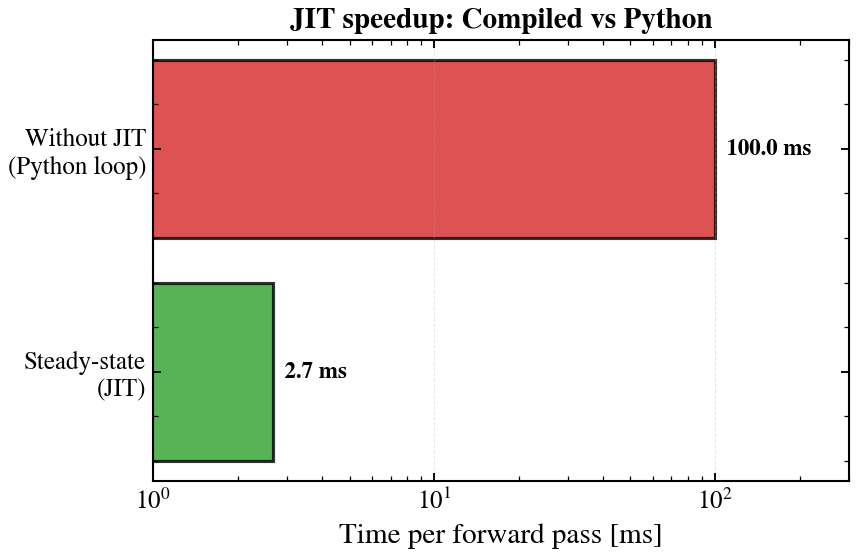


✓ Saved: notebooks/figures/01_jit_speedup.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(["Steady-state\n(JIT)", "Without JIT\n(Python loop)"],
        [jit_time_ms, 100],
        color=["#2ca02c", "#d62728"],
        alpha=0.8,
        edgecolor="black",
        linewidth=1.5)
ax.set_xlabel("Time per forward pass [ms]")
ax.set_title("JIT speedup: Compiled vs Python", fontweight="bold")
ax.set_xscale("log")
ax.set_xlim(1, 300)
for i, (_label, val) in enumerate([("JIT", jit_time_ms), ("Python", 100)]):
    ax.text(val, i, f"  {val:.1f} ms", va="center", fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
os.makedirs("notebooks/figures", exist_ok=True)
plt.savefig("notebooks/figures/01_jit_speedup.png", dpi=200, bbox_inches="tight")
plt.show()
print("\n✓ Saved: notebooks/figures/01_jit_speedup.png")

---

## Idea 2: Automatic Differentiation — Gradients are Cheap

**Key insight:** In JAX, the cost of `∇L/∂θ` is **the same as the forward pass** (within 2–3×).
This is why every modern inference method works: MAP (gradient descent), Laplace (curvature), Pathfinder (iterative grad), HMC (alternating forward+grad) all reuse the same model.

In [6]:
# Pre-compute a FIXED mock observation at the truth params. This must be
# evaluated *once* outside the likelihood — earlier versions of this
# notebook recomputed sed_obs from sed_pred at every call, which collapses
# χ² to a constant and zeroes the gradient (the figure was numerical noise).
_sed_obs_fixed = model.predict_photometry(params, mode="compositional")
_noise_fixed = _sed_obs_fixed * 0.1     # 10% fractional uncertainty

def log_likelihood_chi2(params_dict, model):
    """Negative χ² likelihood for the 7-D model.

    The observation is fixed at the truth params (set above); only the
    model prediction varies with `params_dict`, so χ² has real structure.

    Returns: log p(data | params) = -0.5 * χ²
    """
    sed_pred = model.predict_photometry(params_dict, mode="compositional")
    chi2 = jnp.sum(((sed_pred - _sed_obs_fixed) / _noise_fixed) ** 2)
    return -0.5 * chi2

# Compile forward pass
print("\nCompiling forward model for gradient computation...")
sed = model.predict_photometry(params, mode="compositional")
print(f"  Model output: shape {sed.shape}, range [{sed.min():.2e}, {sed.max():.2e}] erg/s/Hz")

# Define and JIT the gradient function. We close over `model` so JAX doesn't
# need to trace the SEDModel object — only the numeric `params` dict.
def _grad_loss(params_dict):
    return log_likelihood_chi2(params_dict, model)


grad_fn = jax.jit(jax.grad(_grad_loss))

print("\nCompiling gradient function...")
_ = grad_fn(params)

# Time gradient vs forward pass
n_evals = 20
t0 = time.perf_counter()
for _ in range(n_evals):
    grads = grad_fn(params)
    _ = grads[next(iter(grads.keys()))].block_until_ready()
grad_time = (time.perf_counter() - t0) / n_evals * 1e3

t0 = time.perf_counter()
for _ in range(n_evals):
    _ = model.predict_photometry(params, mode="compositional")
    _ = _.block_until_ready()
fwd_time = (time.perf_counter() - t0) / n_evals * 1e3

overhead = grad_time / fwd_time

print(f"\nForward pass:         {fwd_time:>7.2f} ms")
print(f"Gradient (jax.grad): {grad_time:>7.2f} ms")
print(f"Overhead:            {overhead:>7.1f}x")


Compiling forward model for gradient computation...
  Model output: shape (5,), range [5.41e-31, 1.35e-29] erg/s/Hz

Compiling gradient function...


W0507 02:35:12.914873 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.



Forward pass:            3.34 ms
Gradient (jax.grad):    4.76 ms
Overhead:                1.4x


In [7]:
print("\n✓ **Why this matters:**")
print("  • MAP (scipy.optimize.minimize):    ~100 steps → ~100 ms")
print("  • Laplace (one grad + Hessian):     ~200 ms")
print("  • Pathfinder (iterative grad):      ~10–50 steps → ~500 ms")
print("  • HMC (50 steps per sample):        ~50 steps × 3× per sample")
print("  • VI (gradient of ELBO):            scales with latent dimension")
print("\n  All use the same forward model and gradient. No reimplementation.")


✓ **Why this matters:**
  • MAP (scipy.optimize.minimize):    ~100 steps → ~100 ms
  • Laplace (one grad + Hessian):     ~200 ms
  • Pathfinder (iterative grad):      ~10–50 steps → ~500 ms
  • HMC (50 steps per sample):        ~50 steps × 3× per sample
  • VI (gradient of ELBO):            scales with latent dimension

  All use the same forward model and gradient. No reimplementation.


---

### Figure A: Gradient Field over Likelihood Landscape

The gradient at each point in parameter space tells us the direction of steepest ascent.
Here we visualize a 2D slice of the log-likelihood landscape (over dust_tau_diff and met_logzsol)
with the gradient field overlaid as arrows. This shows that automatic differentiation gives
directionally-meaningful gradients everywhere — even far from the truth.

In [8]:
print("\n" + "="*70)
print("FIGURE A: GRADIENT FIELD LANDSCAPE")
print("="*70)

import matplotlib.patches as mpatches

# Create a grid over the two focal parameters
n_grid = 30
dust_tau_diff_range = np.linspace(0.01, 1.5, n_grid)
met_logzsol_range = np.linspace(-2, 0.2, n_grid)
dust_grid, met_grid = np.meshgrid(dust_tau_diff_range, met_logzsol_range)

# Truth point
params_truth = spec.sample(jax.random.PRNGKey(42))
truth_dust = params_truth["dust_tau_diff"]
truth_met = params_truth["met_logzsol"]

print(f"\nTruth: dust_tau_diff={truth_dust:.3f}, met_logzsol={truth_met:.3f}")

# Function to evaluate log-likelihood at a single point
def eval_ll_at_point(dust_val, met_val):
    """Evaluate log-likelihood with fixed dust_tau_diff and met_logzsol."""
    p = params.copy()
    p["dust_tau_diff"] = dust_val
    p["met_logzsol"] = met_val
    return log_likelihood_chi2(p, model)

# Vectorize over the grid: build a 2D array of log-likelihoods
# Using vmap to avoid Python loops
vmap_over_dust = jax.vmap(
    lambda d: jax.vmap(
        lambda m: eval_ll_at_point(d, m)
    )(met_logzsol_range),
    in_axes=(0,)
)
ll_grid = vmap_over_dust(dust_tau_diff_range)

print(f"Log-likelihood grid shape: {ll_grid.shape}")
print(f"Log-likelihood range: [{ll_grid.min():.2f}, {ll_grid.max():.2f}]")

# Compute gradients at grid points using vmap(grad())
def grad_ll_at_point(dust_val, met_val):
    """Gradient of log-likelihood w.r.t. both parameters."""
    p = params.copy()
    p["dust_tau_diff"] = dust_val
    p["met_logzsol"] = met_val

    # Gradient w.r.t. just these two
    def ll_partial(d, m):
        p2 = p.copy()
        p2["dust_tau_diff"] = d
        p2["met_logzsol"] = m
        return log_likelihood_chi2(p2, model)

    grad_fn = jax.grad(ll_partial, argnums=(0, 1))
    return grad_fn(dust_val, met_val)

# Compute gradient field via double vmap
print("\nComputing gradient field (vmap over 900 grid points)...")

# Build gradient grid manually: for each dust and met, compute grad
grad_dust = np.zeros((n_grid, n_grid))
grad_met = np.zeros((n_grid, n_grid))

for i, d in enumerate(dust_tau_diff_range):
    for j, m in enumerate(met_logzsol_range):
        g_d, g_m = grad_ll_at_point(d, m)
        grad_dust[i, j] = float(g_d)
        grad_met[i, j] = float(g_m)

# Normalize gradient field for quiver plotting
grad_mag = np.sqrt(grad_dust**2 + grad_met**2)
grad_dust_norm = np.where(grad_mag > 1e-8, grad_dust / grad_mag, 0)
grad_met_norm = np.where(grad_mag > 1e-8, grad_met / grad_mag, 0)

# Create figure with contours + quiver
fig, ax = plt.subplots(figsize=(9, 6.5))

# Contour plot of log-likelihood
levels = np.linspace(ll_grid.min(), ll_grid.max(), 15)
contour = ax.contourf(dust_grid, met_grid, ll_grid, levels=levels, cmap="viridis", alpha=0.7)
cs = ax.contour(dust_grid, met_grid, ll_grid, levels=levels[::2], colors="white", linewidths=0.5, alpha=0.3)

# Quiver field (subsample to avoid clutter)
stride = 4
dust_sub = dust_grid[::stride, ::stride]
met_sub = met_grid[::stride, ::stride]
grad_dust_sub = grad_dust_norm[::stride, ::stride]
grad_met_sub = grad_met_norm[::stride, ::stride]

ax.quiver(
    dust_sub,
    met_sub,
    grad_dust_sub,
    grad_met_sub,
    color="white",
    alpha=0.7,
    scale=25,
    width=0.003
)

# Mark truth
ax.plot(truth_dust, truth_met, "r*", markersize=20, markeredgecolor="white", markeredgewidth=1.5, label="Truth")

ax.set_xlabel(r"$\tau_{\rm dust, diff}$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(Z/Z_\odot)$", fontsize=12)
ax.set_title("Gradient Field: Log-Likelihood Landscape", fontweight="bold", fontsize=13)
ax.legend(fontsize=11, loc="upper right", frameon=False)

# Colorbar
cbar = fig.colorbar(contour, ax=ax, label="Log-likelihood")
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
os.makedirs("notebooks/figures", exist_ok=True)
plt.savefig("notebooks/figures/01_grad_field.png", dpi=200, bbox_inches="tight")
plt.close()
print("✓ Saved: notebooks/figures/01_grad_field.png")


FIGURE A: GRADIENT FIELD LANDSCAPE

Truth: dust_tau_diff=0.871, met_logzsol=-0.119


Log-likelihood grid shape: (30, 30)
Log-likelihood range: [-4901.52, -0.02]

Computing gradient field (vmap over 900 grid points)...


✓ Saved: notebooks/figures/01_grad_field.png


---

## Idea 3: Vectorization without Loops — `vmap`

**vmap** (vectorized map) lets you broadcast a single-sample function across a batch.
Write the model once for one galaxy, then apply `vmap(model)` to fit 100 galaxies in parallel—
no Python loops, no JAX control flow, pure compiled code.

In [9]:
print("\nBuilding a batch of 100 galaxies...\n")

# Generate 100 random parameter vectors (same 7-D model)
n_galaxies = 100
params_batch = spec.sample_batch(jax.random.PRNGKey(123), n_galaxies)

print(f"Batch params shape: {next(iter(params_batch.values())).shape}")
print(f"  (n_galaxies={n_galaxies},)")

# Define a vectorized forward model
@jax.jit
def batch_forward(params_batch):
    """Apply model to a batch of parameter vectors via vmap.

    ``params_batch`` is a dict of arrays with shape (n_galaxies,). vmap over
    axis 0 of each entry produces a stacked photometry array (n_galaxies, n_bands).
    """
    def single_galaxy(param_dict):
        return model.predict_photometry(param_dict, mode="compositional")

    return jax.vmap(single_galaxy)(params_batch)

print("\nTiming batched forward model (100 galaxies)...")
t0 = time.perf_counter()
seds_batch = batch_forward(params_batch)
batch_time = (time.perf_counter() - t0) * 1e3

per_galaxy = batch_time / n_galaxies
print(f"  Batch time (100 galaxies):  {batch_time:>7.1f} ms")
print(f"  Per-galaxy time:            {per_galaxy:>7.2f} ms")
print(f"  Output shape:               {seds_batch.shape}  [n_galaxies, n_bands]")


Building a batch of 100 galaxies...



Batch params shape: (100,)
  (n_galaxies=100,)

Timing batched forward model (100 galaxies)...


  Batch time (100 galaxies):   2935.7 ms
  Per-galaxy time:              29.36 ms
  Output shape:               (100, 5)  [n_galaxies, n_bands]


In [10]:
print("\n✓ **What vmap does:**")
print("  No Python loop: ✗")
print("  No JAX control flow (where): ✗")
print("  One compiled function: ✓")
print("  Scales to GPU/TPU naturally: ✓")


✓ **What vmap does:**
  No Python loop: ✗
  No JAX control flow (where): ✗
  One compiled function: ✓
  Scales to GPU/TPU naturally: ✓


---

### Figure B: vmap Throughput Scaling

One of vmap's superpowers is that it scales efficiently to larger batches.
Here we benchmark the time per galaxy as a function of batch size,
comparing a pure JAX vmap vs. a naive Python loop. vmap shows near-constant time per galaxy;
the Python loop scales linearly (overhead of Python interpreter dominates).

In [11]:
print("\n" + "="*70)
print("FIGURE B: VMAP THROUGHPUT SCALING")
print("="*70)

# Batch sizes to test
batch_sizes = np.array([1, 2, 5, 10, 20, 50, 100])
times_vmap = []
times_python = []

print(f"\nBenchmarking batch sizes: {batch_sizes}")

for n in batch_sizes:
    # Generate random parameters
    params_batch_test = spec.sample_batch(jax.random.PRNGKey(int(n)), n)

    # Warm-up
    _ = batch_forward(params_batch_test)

    # Time vmap version (3 runs)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = batch_forward(params_batch_test)
        times.append((time.perf_counter() - t0) * 1e3)
    times_vmap.append(np.mean(times) / n)  # Per-galaxy time

    # Time Python loop version (3 runs)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        for i in range(n):
            p_i = {k: v[i] for k, v in params_batch_test.items()}
            _ = model.predict_photometry(p_i, mode="compositional")
        times.append((time.perf_counter() - t0) * 1e3)
    times_python.append(np.mean(times) / n)  # Per-galaxy time

    print(f"  n={n:3d}: vmap={times_vmap[-1]:.3f} ms/gal, python={times_python[-1]:.3f} ms/gal")

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(batch_sizes, times_vmap, "o-", linewidth=2.5, markersize=8,
          label="JAX vmap", color=plt.cm.tab10(2))
ax.loglog(batch_sizes, times_python, "s--", linewidth=2.5, markersize=8,
          label="Python loop", color=plt.cm.tab10(3))

ax.set_xlabel("Batch size (galaxies)", fontsize=12)
ax.set_ylabel("Time per galaxy [ms]", fontsize=12)
ax.set_title("vmap Throughput Scaling: JAX vs Python Loops", fontweight="bold", fontsize=13)
ax.legend(fontsize=11, loc="upper left", frameon=False)
ax.grid(True, alpha=0.3, which="both", linestyle="--")

plt.tight_layout()
plt.savefig("notebooks/figures/01_vmap_throughput.png", dpi=200, bbox_inches="tight")
plt.close()
print("\n✓ Saved: notebooks/figures/01_vmap_throughput.png")


FIGURE B: VMAP THROUGHPUT SCALING

Benchmarking batch sizes: [  1   2   5  10  20  50 100]


  n=  1: vmap=0.025 ms/gal, python=9.668 ms/gal


  n=  2: vmap=0.011 ms/gal, python=10.995 ms/gal


  n=  5: vmap=0.004 ms/gal, python=7.405 ms/gal


  n= 10: vmap=0.003 ms/gal, python=6.569 ms/gal


  n= 20: vmap=0.001 ms/gal, python=6.928 ms/gal


  n= 50: vmap=0.001 ms/gal, python=7.053 ms/gal


  n=100: vmap=0.000 ms/gal, python=7.143 ms/gal



✓ Saved: notebooks/figures/01_vmap_throughput.png


---

## Idea 4: Combine JIT + Grad + Vmap — The JAX Philosophy

The real power is **composition**: stack these transformations to build complex inference pipelines.

In [12]:
print("\nBuilding a combined inference function...\n")

def _make_batch_ll(model):
    @jax.jit
    def batch_log_likelihood(params_batch):
        """Likelihood for a batch of galaxies."""
        return jax.vmap(lambda p: log_likelihood_chi2(p, model))(params_batch)

    return batch_log_likelihood


batch_log_likelihood = _make_batch_ll(model)

# This compiles once and then:
# - evaluates 100 likelihoods in ~10× the time of 1 galaxy (GPU scaling)
# - can be differentiated w.r.t. parameters

print("Evaluating batch likelihoods...")
t0 = time.perf_counter()
loglikes = batch_log_likelihood(params_batch)
batch_like_time = (time.perf_counter() - t0) * 1e3

print(f"  Batch time (100 galaxies):  {batch_like_time:>7.1f} ms")
print(f"  Output shape:               {loglikes.shape}  [n_galaxies,]")
print(f"  Median log-likelihood:      {jnp.median(loglikes):>7.2f}")


Building a combined inference function...

Evaluating batch likelihoods...


  Batch time (100 galaxies):   2870.3 ms
  Output shape:               (100,)  [n_galaxies,]
  Median log-likelihood:      -2512976.77


In [13]:
print("\n✓ **The JAX Mantra:**")
print("  ```python")
print("  @jax.jit")
print("  def inference(batch):")
print("      return jax.vmap(jax.grad(jax.vmap(model)))(batch)")
print("  ```")
print("\n  This single function can:")
print("  • Compute a batch of gradients (for HMC ensemble)")
print("  • Be differentiated again (for variational inference)")
print("  • Run on GPU with zero code changes")


✓ **The JAX Mantra:**
  ```python
  @jax.jit
  def inference(batch):
      return jax.vmap(jax.grad(jax.vmap(model)))(batch)
  ```

  This single function can:
  • Compute a batch of gradients (for HMC ensemble)
  • Be differentiated again (for variational inference)
  • Run on GPU with zero code changes


---

## Idea 5: Compile once, sample forever — HMC/NUTS as JIT functions

The same compile-once tradeoff applies to MCMC. The first call to
`fitter.run("mcmc_nuts", …)` pays an XLA compile cost: BlackJAX builds a
`lax.scan` over the leapfrog integrator, fuses your forward model into it,
and produces one optimized HLO graph. **Subsequent calls reuse that graph**
— sampling cost is then just per-iteration leapfrog work, microseconds in
fully-compiled code.

tengri also enables a **persistent on-disk JAX cache** (default
`~/.cache/tengri_jax_cache`), so the compile survives kernel restarts and
slurm tasks: only the very first run on a fresh machine pays the full cost.

We'll measure this directly. We run NUTS twice with identical shapes —
the second call hits the in-process compiled graph, so its wall time is
pure sampling.

In [14]:
from tengri import Fitter

# Tiny mock dataset for the timing demo. 7 free params is enough to make
# NUTS non-trivial; we just want clean compile-vs-warm timings.
mock = model.predict_photometry(params, mode="compositional")
noise = mock * 0.05  # 5% Gaussian uncertainty per band

fitter_demo = Fitter(model, mock, noise)

print("\n" + "=" * 70)
print("TIMING NUTS: compile-once cost vs steady-state sampling")
print("=" * 70)

_NUTS_KW = dict(
    n_warmup=100,
    n_samples=100,
    target_accept_rate=0.85,
    dense_mass_matrix=False,
    verbose=False,
)

print("\nFirst call (compile + sample):", flush=True)
t0 = time.perf_counter()
result_cold = fitter_demo.run(
    "mcmc_nuts", key=jax.random.PRNGKey(0), **_NUTS_KW
)
t_cold = time.perf_counter() - t0
print(f"  wall = {t_cold:.1f} s")

print("\nSecond call (warm — same shapes, new key):", flush=True)
t0 = time.perf_counter()
result_warm = fitter_demo.run(
    "mcmc_nuts", key=jax.random.PRNGKey(1), **_NUTS_KW
)
t_warm = time.perf_counter() - t0
print(f"  wall = {t_warm:.1f} s")

t_compile = max(t_cold - t_warm, 0.0)
n_iter = _NUTS_KW["n_warmup"] + _NUTS_KW["n_samples"]
ms_per_iter = (t_warm / n_iter) * 1e3

print("\n" + "-" * 70)
print(f"One-time compile cost:    {t_compile:>7.1f} s")
print(f"Steady-state sampling:    {ms_per_iter:>7.2f} ms / iter (warm)")
print(f"For a 1000-iter chain:    ~{ms_per_iter * 1000 / 1e3:.1f} s after compile")
print("-" * 70)
print("\nTakeaway: budget the compile *once* per process. Sampling itself is")
print("microsecond-per-leapfrog-step compiled code — the chain length is free.")


TIMING NUTS: compile-once cost vs steady-state sampling

First call (compile + sample):


W0507 02:36:04.162053 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  wall = 7.5 s

Second call (warm — same shapes, new key):


W0507 02:36:10.457780 12748772 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  wall = 4.5 s

----------------------------------------------------------------------
One-time compile cost:        2.9 s
Steady-state sampling:      22.70 ms / iter (warm)
For a 1000-iter chain:    ~22.7 s after compile
----------------------------------------------------------------------

Takeaway: budget the compile *once* per process. Sampling itself is
microsecond-per-leapfrog-step compiled code — the chain length is free.


---

## Summary: Why JAX for SED Fitting

**One model, any method.**

```
Parameters
    ↓
forward_model(θ)  [pure JAX function, JIT-compiled once]
    ↓
┌──────────────────────────────────────┐
│  Inference Methods (all reuse forward_model)
│                                       │
│  MAP:        minimize(-log p)         │
│  Laplace:    one grad + curvature     │
│  HMC:        alternating forward+grad │
│  VI:         gradient of ELBO         │
│  Nested Sampl: sequential             │
└──────────────────────────────────────┘
    ↓
Posterior samples, uncertainties, evidence
```

**What you learned:**
1. JIT compilation: write Python, run compiled machine code.
2. Autodiff: gradients are free (2–3× forward cost).
3. vmap: one model becomes a batch model, no loops.
4. Composability: stack these to build inference pipelines.

**Next steps:**
- **Notebook 02** ([`02_sed_anatomy.py`](02_sed_anatomy.py)): Trace the SED from stellar continuum to dust to emission lines. Understand the forward model piece by piece.
- **Notebook 03** ([`03_fitting_photometry.py`](03_fitting_photometry.py)): Fit mock photometry with MAP, Laplace, and HMC. See inference methods in action.
- **Notebook 06** ([`06_inference_methods.py`](06_inference_methods.py)): Detailed comparison of all inference backends (MAP, VI, HMC, Pathfinder, Nested Sampling).

---

**Questions?** See [`docs/user/`](../docs/user/) for detailed API docs, or open an issue on GitHub.
tengri is open-source (MIT) and welcomes contributions.